# Functional Bayesian Networks with pgmpy

This notebook demonstrates how to work with Functional Bayesian Networks (FBNs) using pgmpy. We'll cover:
1. Defining a Functional BN
2. Simulating data from it
3. Fitting a functional BN

Functional BNs use deterministic functions instead of probability tables to define relationships between variables.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pgmpy.models import FunctionalBayesianNetwork
from pgmpy.factors.hybrid import FunctionalCPD
from pgmpy.sampling import BayesianModelSampling
from pgmpy.inference import VariableElimination
import random
import torch
import pyro.distributions as dist
import pyro

print("Libraries imported successfully!")

/home/sailesh/ESOC/pgmpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


## 1. Defining a Functional Bayesian Network

Let's create a simple example: a student's performance model where:
- **Intelligence** (I): Root node with random distribution
- **StudyHours** (S): Root node with random distribution  
- **Grade** (G): Functionally determined by Intelligence and StudyHours
- **Recommendation** (R): Functionally determined by Grade

In FunctionalBayesianNetwork, ALL nodes must have FunctionalCPDs, including root nodes.

In [2]:
# Define the network structure
model = FunctionalBayesianNetwork([('Intelligence', 'Grade'), 
                                  ('StudyHours', 'Grade'),
                                  ('Grade', 'Recommendation')])

print("Functional Bayesian Network structure:")
print(f"Nodes: {list(model.nodes())}")
print(f"Edges: {list(model.edges())}")

INFO:pgmpy:Functional BN requires pytorch backend. Switching.


Functional Bayesian Network structure:
Nodes: ['Intelligence', 'Grade', 'StudyHours', 'Recommendation']
Edges: [('Intelligence', 'Grade'), ('Grade', 'Recommendation'), ('StudyHours', 'Grade')]


In [3]:
# Define functional CPDs for root nodes
# For root nodes, we use functions that generate random values

def intelligence_distribution(parents):
    """
    Learnable distribution:
    - p_intelligence = [P(Low), P(High)], initialized as [0.6, 0.4]
    """
    probs = pyro.param(
        "p_intelligence", 
        torch.tensor([0.6, 0.4], dtype=torch.float),
        constraint=dist.constraints.simplex
    )
    return dist.Categorical(probs=probs)

def study_hours_distribution(parents):
    """
    Returns a Pyro distribution representing:
    - 30% chance of Few (0)
    - 50% chance of Moderate (1)
    - 20% chance of Many (2)
    """
    probs = pyro.param(
        "p_study_hours",
        torch.tensor([0.3, 0.5, 0.2], dtype=torch.float),
        constraint=dist.constraints.simplex
    )
    return dist.Categorical(probs=probs)
# Create FunctionalCPDs for root nodes
cpd_intelligence = FunctionalCPD(
    variable='Intelligence',
    fn=intelligence_distribution
)

cpd_study = FunctionalCPD(
    variable='StudyHours',
    fn=study_hours_distribution,
)

print("Root node Functional CPDs defined:")


Root node Functional CPDs defined:


In [4]:
def compute_grade(parents):
    """
    Grade based on Intelligence and Study Hours:
    - Total score = Intelligence + StudyHours
    - Score 0: Grade F (0)
    - Score 1: Grade C (1)
    - Score 2: Grade B (2)
    - Score 3 or more: Grade A (3)
    """
    intelligence = parents["Intelligence"]
    study_hours = parents["StudyHours"]

    if not torch.is_tensor(intelligence):
        intelligence = torch.tensor(intelligence)
    if not torch.is_tensor(study_hours):
        study_hours = torch.tensor(study_hours)

    score = intelligence + study_hours  # works element-wise or scalar

    grade = torch.where(score == 0, torch.tensor(0, device=score.device),
            torch.where(score == 1, torch.tensor(1, device=score.device),
            torch.where(score == 2, torch.tensor(2, device=score.device),
                        torch.tensor(3, device=score.device))))

    return dist.Delta(grade)


# Create FunctionalCPD for Grade
cpd_grade = FunctionalCPD(
    variable='Grade',
    parents=['Intelligence', 'StudyHours'],
    fn=compute_grade,
)

print("Grade Functional CPD created:")


Grade Functional CPD created:


In [5]:
def compute_recommendation(parents):
    """
    Recommendation based on Grade:
    - F, C (0 or 1): No recommendation (0)
    - B (2): Conditional recommendation (1)
    - A (3 or more): Strong recommendation (2)
    """
    grade = parents["Grade"]

    # Convert to tensor if it's a Python scalar
    if not torch.is_tensor(grade):
        grade = torch.tensor(grade)

    # Compute recommendation based on conditions
    recommendation = torch.where(grade <= 1, torch.tensor(0, device=grade.device),
                     torch.where(grade == 2, torch.tensor(1, device=grade.device),
                                 torch.tensor(2, device=grade.device)))  # grade >= 3

    return dist.Delta(recommendation)

# Create FunctionalCPD for Recommendation
cpd_recommendation = FunctionalCPD(
    variable='Recommendation',
    parents=['Grade'],
    fn=compute_recommendation,
)

print("Recommendation Functional CPD created:")
print(f"Function: Recommendation = f(Grade)")


Recommendation Functional CPD created:
Function: Recommendation = f(Grade)


In [6]:
# Add all CPDs to the model
model.add_cpds(cpd_intelligence, cpd_study, cpd_grade, cpd_recommendation)

# Verify the model
print("Model validation:")
print(f"Model is valid: {model.check_model()}")
print(f"\nCPDs in model: {[cpd.variable for cpd in model.get_cpds()]}")

Model validation:
Model is valid: True

CPDs in model: ['Intelligence', 'StudyHours', 'Grade', 'Recommendation']


## 2. Simulating Data from the Functional BN

Now let's generate sample data from our functional Bayesian network to see how the deterministic relationships work.

In [7]:
samples = model.simulate(n_samples=1000, seed=42)

print("Generated 1000 samples from the Functional BN:")
print(samples.head(10))
print(f"\nDataset shape: {samples.shape}")
print(f"Columns: {list(samples.columns)}")

Generated 1000 samples from the Functional BN:
   Intelligence  StudyHours  Grade  Recommendation
0             0           2      2               1
1             1           0      1               0
2             0           0      0               0
3             0           2      2               1
4             0           1      1               0
5             0           1      1               0
6             0           2      2               1
7             0           2      2               1
8             0           1      1               0
9             1           1      2               1

Dataset shape: (1000, 4)
Columns: ['Intelligence', 'StudyHours', 'Grade', 'Recommendation']


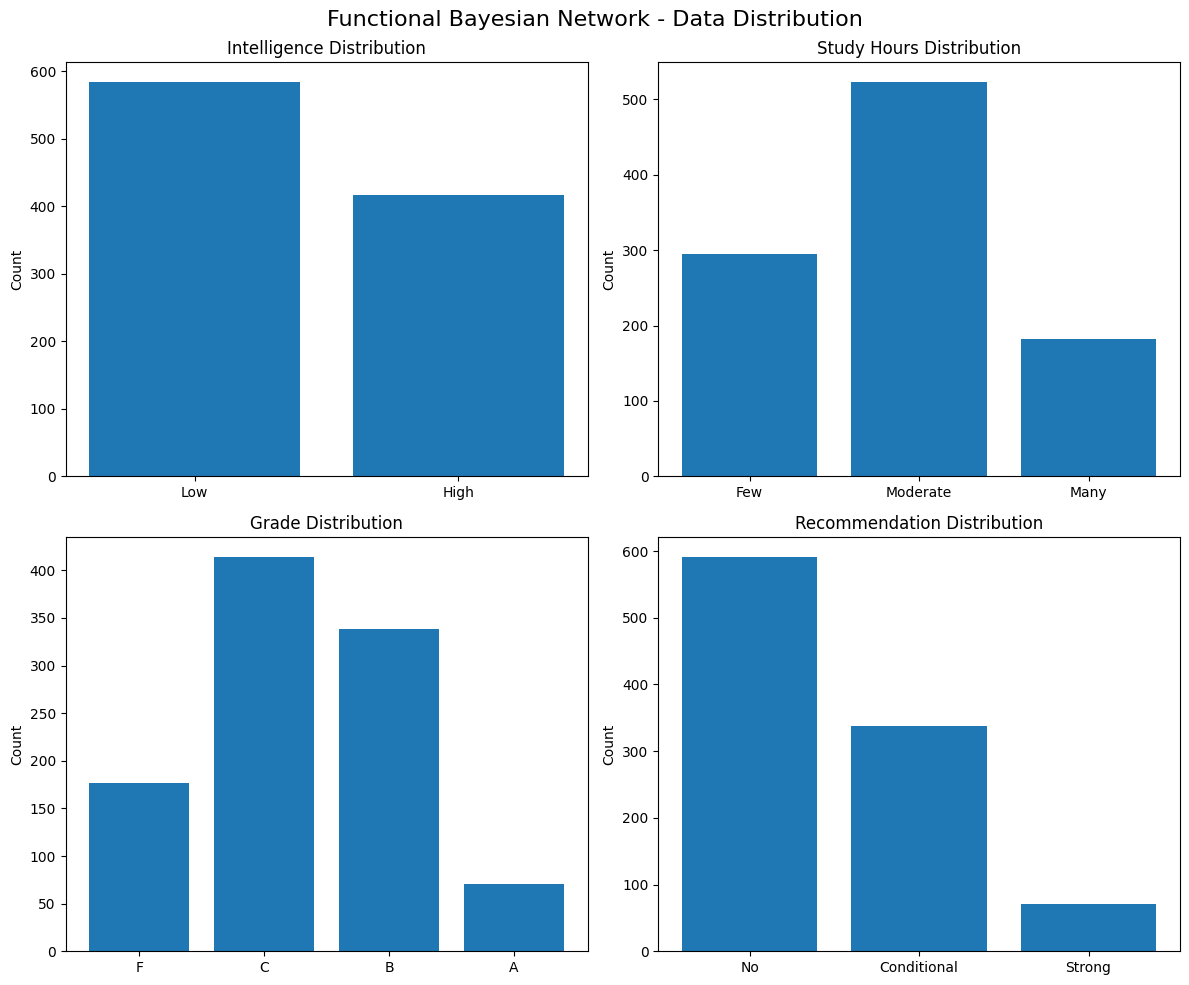

In [8]:
# Visualize the data
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Functional Bayesian Network - Data Distribution', fontsize=16)

# Intelligence distribution
intelligence_counts = samples['Intelligence'].value_counts().sort_index()
axes[0,0].bar(['Low', 'High'], intelligence_counts.values)
axes[0,0].set_title('Intelligence Distribution')
axes[0,0].set_ylabel('Count')

# StudyHours distribution
study_counts = samples['StudyHours'].value_counts().sort_index()
axes[0,1].bar(['Few', 'Moderate', 'Many'], study_counts.values)
axes[0,1].set_title('Study Hours Distribution')
axes[0,1].set_ylabel('Count')

# Grade distribution
grade_counts = samples['Grade'].value_counts().sort_index()
axes[1,0].bar(['F', 'C', 'B', 'A'], grade_counts.values)
axes[1,0].set_title('Grade Distribution')
axes[1,0].set_ylabel('Count')

# Recommendation distribution
rec_counts = samples['Recommendation'].value_counts().sort_index()
axes[1,1].bar(['No', 'Conditional', 'Strong'], rec_counts.values)
axes[1,1].set_title('Recommendation Distribution')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Fitting a Functional BN from Data

Now let's demonstrate how to learn/fit a functional BN from observed data. We'll use the data we generated and try to recover the functional relationships.

In [9]:
params = model.fit(samples, method="SVI", 
                   optimizer=pyro.optim.Adam({"lr": 0.05}),
                   seed=42, num_steps=100)


print(params)

INFO:pgmpy:Step 0 | Loss: 1690.1047
INFO:pgmpy:Step 50 | Loss: 1688.1774


{'p_intelligence': tensor([0.5840, 0.4160], grad_fn=<DivBackward0>), 'p_study_hours': tensor([0.2951, 0.5230, 0.1820], grad_fn=<DivBackward0>)}


## Summary

This notebook demonstrated:

1. **Defining a Functional BN**: We created a `FunctionalBayesianNetwork` with deterministic relationships using `FunctionalCPD`s

2. **Simulating Data**: We generated sample data where child nodes are deterministically computed from parent nodes

3. **Fitting a Functional BN**: We learned functional relationships from observed data and created a new model


This approach is useful when you have exact functional relationships between variables rather than probabilistic dependencies.